# Train, Predict, and Evaluate Ultralytics Segmentation on DIVA-HisDB

This notebook lets you choose one DIVA-HisDB subset (`CB55`, `CS18`, or `CS863`), build a YOLO segmentation dataset from the existing COCO polygons, train an Ultralytics segmentation model, export PAGE XML predictions for the public test split, save overlay images, and evaluate them with both HSCP and DIVA metrics.

The PAGE XML export and the two metric computations follow the same overall evaluation logic used by the `50_modelling/2stage` pipeline.

Change only the configuration cell first, then run the notebook from top to bottom.

In [13]:
from __future__ import annotations

import shutil
import subprocess
import sys
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path
from uuid import uuid4
from xml.dom import minidom

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import torch
from tqdm.auto import tqdm
import yaml
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "00_data").exists() and (candidate / "50_modelling").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_repo_root(Path.cwd().resolve())
TWOSTAGE_DIR = PROJECT_ROOT / "50_modelling" / "2stage"
if str(TWOSTAGE_DIR) not in sys.path:
    sys.path.insert(0, str(TWOSTAGE_DIR))

from dataset import create_page_xml, parse_xml_polygons, polygon_to_baseline, polygon_to_mask

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"Project root: {PROJECT_ROOT}")
print(f"2stage helper dir: {TWOSTAGE_DIR}")
print(f"Device: {DEVICE}")

Project root: /home/artur/Thesis/fsl-tl-manuscripts
2stage helper dir: /home/artur/Thesis/fsl-tl-manuscripts/50_modelling/2stage
Device: 0


In [14]:
DIVA_SUBSET = "CS863"  # "CB55" | "CS18" | "CS863"
MODEL_WEIGHTS = "yolov8n-seg.pt"
FORCE_RETRAIN = False
FORCE_REBUILD_DATASET = False
FORCE_REEXPORT_XML = True

EPOCHS = 100
IMGSZ = 1024
BATCH = 4
WORKERS = 2
PATIENCE = 20
PRED_CONF = 0.5

DIVA_EVALUATOR_JAR = Path("/home/artur/Thesis/DIVA_Line_Segmentation_Evaluator/out/artifacts/LineSegmentationEvaluator.jar")
OPENJFX_LIB_DIR = Path("/usr/share/openjfx/lib")

DIVA_INFO = {
    "CB55": {
        "coco_dir": "coco_dataset_CB55",
        "image_dir": "CB55/img-CB55/img",
        "task2_page_dir": "CB55/PAGE-gt-CB55-TASK-2/TASK-2",
        "pixel_dir": "CB55/pixel-level-gt-CB55/pixel-level-gt",
    },
    "CS18": {
        "coco_dir": "coco_dataset_CS18",
        "image_dir": "CS18/img-CS18/img",
        "task2_page_dir": "CS18/PAGE-gt-CS18-TASK-2/TASK-2",
        "pixel_dir": "CS18/pixel-level-gt-CS18/pixel-level-gt",
    },
    "CS863": {
        "coco_dir": "coco_dataset_CS863",
        "image_dir": "CS863/img-CS863/img",
        "task2_page_dir": "CS863/PAGE-gt-CS863-TASK-2/TASK-2",
        "pixel_dir": "CS863/pixel-level-gt-CS863/pixel-level-gt",
    },
}

subset_key = DIVA_SUBSET.upper()
if subset_key not in DIVA_INFO:
    raise ValueError(f"Unsupported subset: {DIVA_SUBSET}")

diva_root = PROJECT_ROOT / "00_data" / "DIVA-HisDB"
subset_info = DIVA_INFO[subset_key]
COCO_ROOT = diva_root / subset_info["coco_dir"]
SOURCE_SPLITS = {
    "train": diva_root / subset_info["image_dir"] / "training",
    "val": diva_root / subset_info["image_dir"] / "validation",
    "test": diva_root / subset_info["image_dir"] / "public-test",
}
TEST_PAGE_DIR = diva_root / subset_info["task2_page_dir"] / "public-test"
TEST_PIXEL_DIR = diva_root / subset_info["pixel_dir"] / "public-test"
YOLO_SEG_ROOT = diva_root / f"yolo_seg_dataset_{subset_key}"
DATASET_YAML = YOLO_SEG_ROOT / "dataset.yaml"

model_stem = MODEL_WEIGHTS.replace("-seg.pt", "").replace(".pt", "")
RUN_NAME = f"ultralytics_{subset_key.lower()}_{model_stem}_seg"
RUNS_ROOT = PROJECT_ROOT / "80_models" / "segmentation"
RUN_DIR = RUNS_ROOT / RUN_NAME
BEST_WEIGHTS = RUN_DIR / "weights" / "best.pt"
PRED_ROOT = PROJECT_ROOT / "99_evaluation" / f"pred_{subset_key.lower()}_ultralytics_{model_stem}_seg"
OVERLAY_DIR = PRED_ROOT / "overlays"

for split_name, split_path in SOURCE_SPLITS.items():
    print(split_name, split_path, split_path.exists())

print("COCO root:", COCO_ROOT, COCO_ROOT.exists())
print("TASK-2 PAGE dir:", TEST_PAGE_DIR, TEST_PAGE_DIR.exists())
print("Pixel GT dir:", TEST_PIXEL_DIR, TEST_PIXEL_DIR.exists())
print("Training run dir:", RUN_DIR)
print("Prediction dir:", PRED_ROOT)

train /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CS863/img-CS863/img/training True
val /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CS863/img-CS863/img/validation True
test /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CS863/img-CS863/img/public-test True
COCO root: /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/coco_dataset_CS863 True
TASK-2 PAGE dir: /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CS863/PAGE-gt-CS863-TASK-2/TASK-2/public-test True
Pixel GT dir: /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CS863/pixel-level-gt-CS863/pixel-level-gt/public-test True
Training run dir: /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/ultralytics_cs863_yolov8n_seg
Prediction dir: /home/artur/Thesis/fsl-tl-manuscripts/99_evaluation/pred_cs863_ultralytics_yolov8n_seg


In [15]:
def copy_split_images(dataset_root: Path) -> None:
    for split_name, source_dir in SOURCE_SPLITS.items():
        target_dir = dataset_root / "images" / split_name
        target_dir.mkdir(parents=True, exist_ok=True)
        for image_path in sorted(source_dir.glob("*.jpg")):
            target_path = target_dir / image_path.name
            if not target_path.exists():
                shutil.copy2(image_path, target_path)


def convert_coco_segments(dataset_root: Path) -> None:
    expected_labels = [dataset_root / "labels" / split for split in SOURCE_SPLITS]
    if all(path.exists() and any(path.glob("*.txt")) for path in expected_labels):
        return

    temp_root = dataset_root.parent / f"{subset_key.lower()}_yolo_seg_{uuid4().hex}"
    try:
        convert_coco(
            labels_dir=str(COCO_ROOT),
            save_dir=str(temp_root),
            use_segments=True,
            cls91to80=False,
        )
        labels_dir = temp_root / "labels"
        target_labels = dataset_root / "labels"
        target_labels.mkdir(parents=True, exist_ok=True)
        for split_name in SOURCE_SPLITS:
            split_source = labels_dir / split_name
            split_target = target_labels / split_name
            if split_target.exists():
                shutil.rmtree(split_target)
            shutil.move(str(split_source), str(split_target))
    finally:
        shutil.rmtree(temp_root, ignore_errors=True)


def write_dataset_yaml(dataset_root: Path) -> None:
    config = {
        "path": str(dataset_root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "names": {0: "textline"},
    }
    with DATASET_YAML.open("w", encoding="utf-8") as handle:
        yaml.safe_dump(config, handle, sort_keys=False)


def summarize_dataset(dataset_root: Path) -> pd.DataFrame:
    summary = {}
    for split_name in SOURCE_SPLITS:
        image_dir = dataset_root / "images" / split_name
        label_dir = dataset_root / "labels" / split_name
        token_counts = Counter()
        for label_file in sorted(label_dir.glob("*.txt")):
            with label_file.open(encoding="utf-8") as handle:
                for line in handle:
                    token_counts[len(line.strip().split())] += 1
        summary[split_name] = {
            "images": len(list(image_dir.glob("*.jpg"))),
            "labels": len(list(label_dir.glob("*.txt"))),
            "polygon_rows": sum(count for tokens, count in token_counts.items() if tokens > 5),
            "bbox_rows": sum(count for tokens, count in token_counts.items() if tokens == 5),
        }
    return pd.DataFrame.from_dict(summary, orient="index")


if FORCE_REBUILD_DATASET and YOLO_SEG_ROOT.exists():
    shutil.rmtree(YOLO_SEG_ROOT)

YOLO_SEG_ROOT.mkdir(parents=True, exist_ok=True)
copy_split_images(YOLO_SEG_ROOT)
convert_coco_segments(YOLO_SEG_ROOT)
write_dataset_yaml(YOLO_SEG_ROOT)
dataset_summary = summarize_dataset(YOLO_SEG_ROOT)
dataset_summary

,images,labels,polygon_rows,bbox_rows
train,20,20,1127,0
val,10,10,536,0
test,10,10,641,0


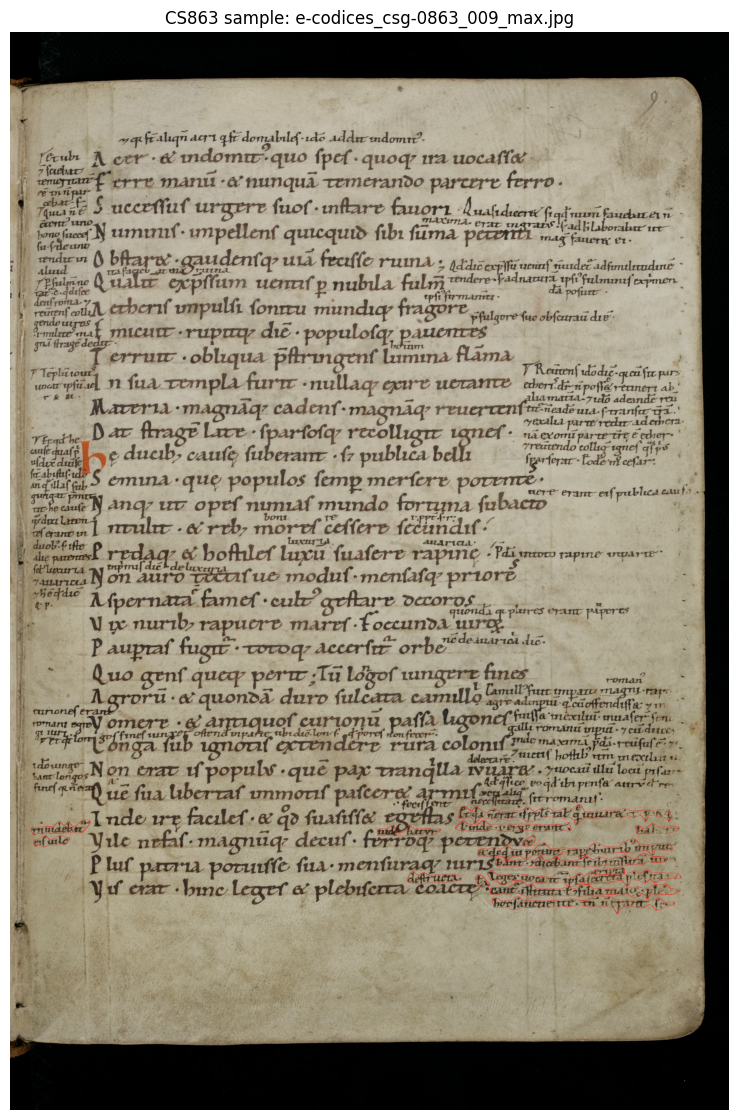

In [16]:
sample_image_path = next(iter(sorted((YOLO_SEG_ROOT / "images" / "train").glob("*.jpg"))))
sample_label_path = YOLO_SEG_ROOT / "labels" / "train" / f"{sample_image_path.stem}.txt"

image = Image.open(sample_image_path).convert("RGB")
overlay = image.copy()
draw = ImageDraw.Draw(overlay)
width, height = image.size

with sample_label_path.open(encoding="utf-8") as handle:
    for row_index, line in enumerate(handle):
        values = [float(token) for token in line.strip().split()]
        if len(values) <= 5:
            continue
        coords = values[1:]
        polygon = [(coords[i] * width, coords[i + 1] * height) for i in range(0, len(coords), 2)]
        draw.line(polygon + [polygon[0]], fill=(255, 0, 0), width=2)
        if row_index >= 14:
            break

plt.figure(figsize=(10, 14))
plt.imshow(overlay)
plt.axis("off")
plt.title(f"{subset_key} sample: {sample_image_path.name}")
plt.show()

## Training and Random Test Preview

This section trains or reloads the segmentation model, runs validation on the configured split, and immediately plots one random prediction from the public test set.

Run this section before the export and metric evaluation cells below.

In [17]:
PAGE_NS = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
IMAGE_SUFFIXES = (".jpg", ".png", ".tif", ".tiff")


def iter_test_images() -> list[Path]:
    image_paths = []
    for suffix in IMAGE_SUFFIXES:
        image_paths.extend(sorted(SOURCE_SPLITS["test"].glob(f"*{suffix}")))
    return sorted(image_paths)


def load_main_textregion_polygon(gt_xml_path: Path) -> np.ndarray | None:
    if not gt_xml_path.exists():
        return None
    root = ET.parse(gt_xml_path).getroot()
    ns = {"p": PAGE_NS}
    best_poly, best_area = None, -1.0
    for region in root.iterfind(".//p:TextRegion", ns):
        coords = region.find("p:Coords", ns)
        if coords is None:
            continue
        poly = np.array(
            [list(map(int, xy.split(","))) for xy in coords.attrib["points"].split()],
            dtype=np.int32,
        )
        area = float(cv2.contourArea(poly))
        if area > best_area:
            best_poly, best_area = poly, area
    return best_poly


def simplify_polygon(points: np.ndarray, epsilon_ratio: float = 0.0025) -> list[tuple[int, int]] | None:
    pts = np.asarray(points, dtype=np.float32)
    if pts.shape[0] < 3:
        return None
    contour = pts.reshape(-1, 1, 2)
    epsilon = epsilon_ratio * cv2.arcLength(contour, True)
    polygon = cv2.approxPolyDP(contour, epsilon, True)
    if polygon.shape[0] < 3:
        polygon = contour
    return [(int(round(point[0][0])), int(round(point[0][1]))) for point in polygon]


def polygon_centroid(points: list[tuple[int, int]]) -> tuple[float, float]:
    arr = np.asarray(points, dtype=np.float32)
    return float(arr[:, 0].mean()), float(arr[:, 1].mean())


def render_overlay(image_bgr: np.ndarray, text_lines: list[dict]) -> np.ndarray:
    overlay = image_bgr.copy()
    rng = np.random.RandomState(42)
    colors = [tuple(int(c) for c in rng.randint(80, 255, size=3)) for _ in text_lines]

    for line, color in zip(text_lines, colors):
        pts = np.array(line["coords"], dtype=np.int32).reshape(-1, 1, 2)
        cv2.fillPoly(overlay, [pts], color)

    blended = cv2.addWeighted(image_bgr, 0.55, overlay, 0.45, 0)
    for line, color in zip(text_lines, colors):
        pts = np.array(line["coords"], dtype=np.int32).reshape(-1, 1, 2)
        cv2.polylines(blended, [pts], isClosed=True, color=color, thickness=2)
        score = line["score"]
        tx, ty = pts[0, 0]
        cv2.putText(blended, f"{score:.2f}", (tx, ty - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)
    return blended


def predict_text_lines(model: YOLO, image_path: Path, image_bgr: np.ndarray) -> list[dict]:
    region_poly = load_main_textregion_polygon(TEST_PAGE_DIR / f"{image_path.stem}.xml")
    result = model.predict(
        source=str(image_path),
        imgsz=IMGSZ,
        conf=PRED_CONF,
        device=DEVICE,
        save=False,
        verbose=False,
    )[0]

    scores = result.boxes.conf.cpu().numpy().tolist() if result.boxes is not None else []
    polygons = result.masks.xy if result.masks is not None else []
    text_lines = []

    for index, points in enumerate(polygons):
        polygon = simplify_polygon(points)
        if polygon is None or len(polygon) < 3:
            continue

        if region_poly is not None:
            cx, cy = polygon_centroid(polygon)
            if cv2.pointPolygonTest(region_poly, (cx, cy), False) < 0:
                continue

        baseline = polygon_to_baseline(polygon)
        if len(baseline) < 2:
            continue

        text_lines.append({
            "coords": polygon,
            "baseline": baseline,
            "score": float(scores[index]) if index < len(scores) else 0.0,
        })

    text_lines.sort(key=lambda row: np.mean([y for _, y in row["coords"]]))
    return text_lines


def plot_random_test_prediction(model: YOLO, seed: int | None = 42) -> str | None:
    image_paths = iter_test_images()
    if not image_paths:
        print("No test images found.")
        return None

    rng = np.random.default_rng(seed)
    image_path = image_paths[int(rng.integers(0, len(image_paths)))]
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        print(f"Could not load image: {image_path}")
        return None

    text_lines = predict_text_lines(model, image_path, image_bgr)
    preview = cv2.cvtColor(render_overlay(image_bgr, text_lines), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 14))
    plt.imshow(preview)
    plt.axis("off")
    plt.title(f"Random test prediction: {image_path.name}")
    plt.show()
    return image_path.name

Reusing existing weights: /home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/ultralytics_cs863_yolov8n_seg/weights/best.pt
Ultralytics 8.4.14 🚀 Python-3.12.3 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7785MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9545.0±7235.1 MB/s, size: 2763.6 KB)
val: Scanning /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/yolo_seg_dataset_CS863/labels/val.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 3.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.5it/s 0.7s0.3s
                   all         10        536      0.876       0.71      0.818      0.512      0.832      0.692       0.79      0.416
Speed: 1.4ms preprocess, 7.3ms inference, 0.0ms loss, 14.9ms postprocess per image


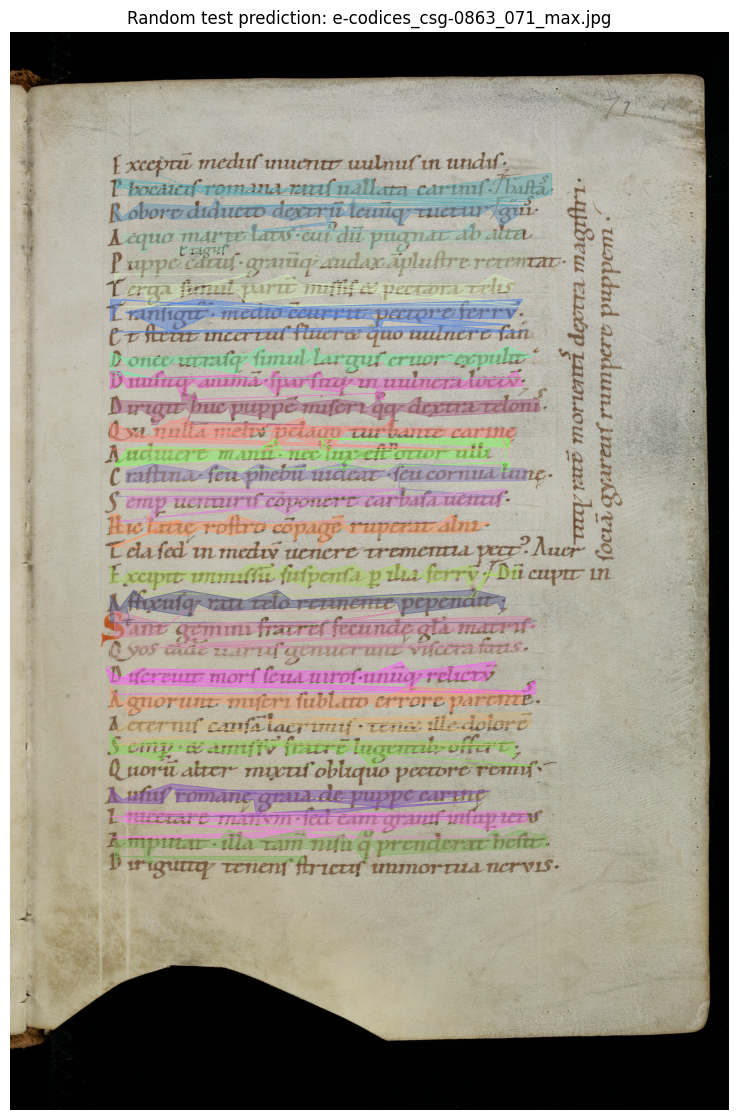

Previewed random test image: e-codices_csg-0863_071_max.jpg


{'best_weights': '/home/artur/Thesis/fsl-tl-manuscripts/80_models/segmentation/ultralytics_cs863_yolov8n_seg/weights/best.pt',
 'box_map50': 0.8179384366926364,
 'box_map50_95': 0.5118994481354774,
 'seg_map50': 0.7895199410386902,
 'seg_map50_95': 0.41595238298730247}

In [18]:
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

if BEST_WEIGHTS.exists() and not FORCE_RETRAIN:
    print(f"Reusing existing weights: {BEST_WEIGHTS}")
    train_results = None
else:
    model = YOLO(MODEL_WEIGHTS)
    train_results = model.train(
        data=str(DATASET_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        workers=WORKERS,
        patience=PATIENCE,
        device=DEVICE,
        project=str(RUNS_ROOT),
        name=RUN_NAME,
        exist_ok=True,
        task="segment",
        plots=True,
        cache=False,
        pretrained=True,
        amp=True,
        mosaic=0.0,
        mixup=0.0,
        copy_paste=0.0,
        fliplr=0.0,
        flipud=0.0,
        degrees=0.0,
        translate=0.0,
        scale=0.0,
        shear=0.0,
        perspective=0.0,
        overlap_mask=False,
        save=True,
        verbose=True,
        deterministic=True,
        seed=42,
        cos_lr=False,
        lr0=0.0001,
        optimizer="AdamW",
    )

if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(
        f"Checkpoint not found at {BEST_WEIGHTS}. Rerun this cell with a lower IMGSZ if training ran out of memory."
    )

best_model = YOLO(str(BEST_WEIGHTS))
val_metrics = best_model.val(
    data=str(DATASET_YAML),
    split="val",
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    plots=False,
    verbose=False,
)

random_image_name = plot_random_test_prediction(best_model, seed=None)
if random_image_name is not None:
    print(f"Previewed random test image: {random_image_name}")

{
    "best_weights": str(BEST_WEIGHTS),
    "box_map50": float(val_metrics.box.map50),
    "box_map50_95": float(val_metrics.box.map),
    "seg_map50": float(val_metrics.seg.map50),
    "seg_map50_95": float(val_metrics.seg.map),
}

## Test-Set Evaluation

This section exports PAGE XML predictions for the public test split and evaluates them with DIVA (`LineIU`, `PixelIU`) and HSCP (`DR`, `RA`, `FM`).

If `FORCE_REEXPORT_XML` is `False` and the PAGE XML files already exist, the evaluation cell reuses them.

In [19]:
def write_prediction_pagexml(image_path: Path, image_bgr: np.ndarray, text_lines: list[dict], output_path: Path) -> None:
    height, width = image_bgr.shape[:2]
    root, region = create_page_xml(str(image_path), width, height)
    for index, line in enumerate(text_lines):
        text_line = ET.SubElement(region, "TextLine", {"id": f"textline_{index}", "custom": "0"})
        ET.SubElement(text_line, "Coords", {"points": " ".join(f"{x},{y}" for x, y in line["coords"])})
        ET.SubElement(text_line, "Baseline", {"points": " ".join(f"{x},{y}" for x, y in line["baseline"])})
        ET.SubElement(ET.SubElement(text_line, "TextEquiv"), "Unicode").text = ""

    output_path.parent.mkdir(parents=True, exist_ok=True)
    xml_str = minidom.parseString(ET.tostring(root, encoding="utf-8")).toprettyxml(indent="  ")
    output_path.write_text(xml_str, encoding="utf-8")


def export_pagexml_predictions(model: YOLO) -> pd.DataFrame:
    PRED_ROOT.mkdir(parents=True, exist_ok=True)

    if FORCE_REEXPORT_XML:
        for xml_path in PRED_ROOT.glob("*.xml"):
            xml_path.unlink()

    rows = []
    for image_path in tqdm(iter_test_images(), desc="Predicting and exporting PAGE XML"):
        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            continue

        text_lines = predict_text_lines(model, image_path, image_bgr)
        write_prediction_pagexml(image_path, image_bgr, text_lines, PRED_ROOT / f"{image_path.stem}.xml")
        rows.append({"image": image_path.name, "predicted_lines": len(text_lines)})

    return pd.DataFrame(rows)


def match_score(mask_gt: np.ndarray, mask_pred: np.ndarray) -> float:
    inter = np.logical_and(mask_gt, mask_pred).sum()
    union = np.logical_or(mask_gt, mask_pred).sum()
    return inter / union if union > 0 else 0.0


def hscp_polygon_eval(gt_xml: Path, pred_xml: Path, height: int, width: int, iou_thresh: float = 0.75) -> dict:
    gt_polys = parse_xml_polygons(str(gt_xml))
    pred_polys = parse_xml_polygons(str(pred_xml))
    n_gt, n_pred = len(gt_polys), len(pred_polys)

    if n_gt == 0 or n_pred == 0:
        return {"DR": 0.0, "RA": 0.0, "FM": 0.0, "M": 0, "N_gt": n_gt, "N_pred": n_pred}

    gt_masks = [polygon_to_mask(poly, height, width) for poly in gt_polys]
    pred_masks = [polygon_to_mask(poly, height, width) for poly in pred_polys]

    used_pred = set()
    matches = 0
    for gt_mask in gt_masks:
        best_index, best_iou = -1, 0.0
        for index, pred_mask in enumerate(pred_masks):
            if index in used_pred:
                continue
            iou = match_score(gt_mask, pred_mask)
            if iou > best_iou:
                best_index, best_iou = index, iou
        if best_iou >= iou_thresh and best_index >= 0:
            matches += 1
            used_pred.add(best_index)

    dr = matches / n_gt if n_gt else 0.0
    ra = matches / n_pred if n_pred else 0.0
    fm = (2 * dr * ra) / (dr + ra) if (dr + ra) > 0 else 0.0
    return {
        "DR": round(dr, 4),
        "RA": round(ra, 4),
        "FM": round(fm, 4),
        "M": matches,
        "N_gt": n_gt,
        "N_pred": n_pred,
    }


def score_hscp(iou_thresh: float = 0.75) -> pd.DataFrame:
    rows = []
    for image_path in tqdm(iter_test_images(), desc="Scoring HSCP"):
        stem = image_path.stem
        pred_xml = PRED_ROOT / f"{stem}.xml"
        gt_xml = TEST_PAGE_DIR / f"{stem}.xml"
        if not pred_xml.exists() or not gt_xml.exists():
            continue
        image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        height, width = image_bgr.shape[:2]
        row = hscp_polygon_eval(gt_xml, pred_xml, height, width, iou_thresh=iou_thresh)
        row["image"] = image_path.name
        rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df.to_csv(PRED_ROOT / "hscp_results.csv", index=False)
        print(f"Mean DR: {df['DR'].mean():.4f}  RA: {df['RA'].mean():.4f}  FM: {df['FM'].mean():.4f}")
    return df


def score_diva() -> pd.DataFrame | None:
    if not DIVA_EVALUATOR_JAR.exists():
        print(f"DIVA evaluator jar not found: {DIVA_EVALUATOR_JAR}")
        return None
    if not OPENJFX_LIB_DIR.exists():
        print(f"OpenJFX lib directory not found: {OPENJFX_LIB_DIR}")
        return None

    out_csv_dir = PRED_ROOT / "eval_csv"
    out_csv_dir.mkdir(parents=True, exist_ok=True)
    java_cp = f"{OPENJFX_LIB_DIR}/*:{DIVA_EVALUATOR_JAR}"

    for pred_xml in tqdm(sorted(PRED_ROOT.glob("*.xml")), desc="Scoring DIVA"):
        stem = pred_xml.stem
        image_path = SOURCE_SPLITS["test"] / f"{stem}.jpg"
        cmd = [
            "java",
            "-cp",
            java_cp,
            "ch.unifr.LineSegmentationEvaluatorTool",
            "-igt",
            str(TEST_PIXEL_DIR / f"{stem}.png"),
            "-xgt",
            str(TEST_PAGE_DIR / f"{stem}.xml"),
            "-xp",
            str(pred_xml),
            "-overlap",
            str(image_path),
            "-csv",
        ]
        try:
            result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, check=True)
            (out_csv_dir / f"{stem}.csv").write_text(result.stdout, encoding="utf-8")
        except subprocess.CalledProcessError as exc:
            print(f"DIVA evaluator failed on {stem}:\n{exc.stderr}")

    frames = []
    for csv_path in sorted(out_csv_dir.glob("*.csv")):
        try:
            frames.append(pd.read_csv(csv_path))
        except Exception as exc:
            print(f"Could not parse {csv_path.name}: {exc}")

    if not frames:
        return None

    df = pd.concat(frames, ignore_index=True)
    df.to_csv(PRED_ROOT / "diva_results.csv", index=False)
    print(f"Mean Line IU: {df['LinesIU'].mean():.4f}")
    print(f"Mean Pixel IU: {df['PixelIU'].mean():.4f}")
    return df

In [ ]:
if not BEST_WEIGHTS.exists():
    raise FileNotFoundError(f"Missing trained weights: {BEST_WEIGHTS}")

best_model = YOLO(str(BEST_WEIGHTS))
prediction_summary = export_pagexml_predictions(best_model)
hscp_results = score_hscp()
diva_results = score_diva()

test_metrics = pd.DataFrame(
    [
        {
            "subset": subset_key,
            "n_test_images": int(len(iter_test_images())),
            "n_prediction_files": int(len(list(PRED_ROOT.glob("*.xml")))),
            "line_iu": float(diva_results["LinesIU"].mean()) if diva_results is not None else None,
            "pixel_iu": float(diva_results["PixelIU"].mean()) if diva_results is not None else None,
            "dr": float(hscp_results["DR"].mean()) if not hscp_results.empty else None,
            "ra": float(hscp_results["RA"].mean()) if not hscp_results.empty else None,
            "fm": float(hscp_results["FM"].mean()) if not hscp_results.empty else None,
        }
    ]
)
test_metrics

prediction_summary.head()

Predicting and exporting PAGE XML:   0%|          | 0/10 [00:00<?, ?it/s]

Scoring HSCP:   0%|          | 0/10 [00:00<?, ?it/s]